## 1. Load & Merge
Combine 5 raw files, drop leftover index columns.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [12]:
dfs = [pd.read_csv(f"../data/FOOD-DATA-GROUP{i}.csv") for i in range(1, 6)]
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])

print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (2395, 35)


,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,14.6,0.016,7.6,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,62.9,0.300,53.6,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,9.8,0.017,14.7,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,8.1,0.046,10.0,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [3]:
df['food'] = df['food'].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

## 2. Initial Inspection
Check dtypes, nulls, duplicates before changing anything.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  2395 non-null   str    
 1   Caloric Value         2395 non-null   int64  
 2   Fat                   2395 non-null   float64
 3   Saturated Fats        2395 non-null   float64
 4   Monounsaturated Fats  2395 non-null   float64
 5   Polyunsaturated Fats  2395 non-null   float64
 6   Carbohydrates         2395 non-null   float64
 7   Sugars                2395 non-null   float64
 8   Protein               2395 non-null   float64
 9   Dietary Fiber         2395 non-null   float64
 10  Cholesterol           2395 non-null   float64
 11  Sodium                2395 non-null   float64
 12  Water                 2395 non-null   float64
 13  Vitamin A             2395 non-null   float64
 14  Vitamin B1            2395 non-null   float64
 15  Vitamin B11           2395 non-n

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  2395 non-null   str    
 1   Caloric Value         2395 non-null   int64  
 2   Fat                   2395 non-null   float64
 3   Saturated Fats        2395 non-null   float64
 4   Monounsaturated Fats  2395 non-null   float64
 5   Polyunsaturated Fats  2395 non-null   float64
 6   Carbohydrates         2395 non-null   float64
 7   Sugars                2395 non-null   float64
 8   Protein               2395 non-null   float64
 9   Dietary Fiber         2395 non-null   float64
 10  Cholesterol           2395 non-null   float64
 11  Sodium                2395 non-null   float64
 12  Water                 2395 non-null   float64
 13  Vitamin A             2395 non-null   float64
 14  Vitamin B1            2395 non-null   float64
 15  Vitamin B11           2395 non-n

In [6]:
df.sample(5)

,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
574,zinfandel red wine,129,0.000,0.000,0.000,0.000,4.2,0.0,0.1,0.000,...,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,4.300
1353,pork blade chops raw,376,15.400,5.200,6.100,2.100,0.0,0.0,55.8,0.000,...,78.9,0.200,1.900,47.300,0.059,594.400,823.2,0.038,7.200,152.089
2380,crimini mushrooms,1,0.018,0.054,0.014,0.025,0.3,0.1,0.2,0.064,...,0.0,1.100,0.098,0.007,0.500,0.048,7.2,26.900,0.038,0.681
845,rice crisps,107,0.400,0.065,0.017,0.090,24.1,2.3,1.8,0.200,...,1.4,0.080,2.900,6.700,0.300,26.900,30.2,0.096,0.300,43.900
711,shortcake,98,4.000,1.100,1.700,1.000,13.7,0.0,1.7,0.000,...,58.0,0.076,0.700,4.500,0.080,40.500,30.0,0.097,0.100,78.182


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values.")
else:
    missing.plot(kind='barh', figsize=(8, 4), title='Missing values per column')
    plt.show()

No missing values.


In [8]:
df[df['Caloric Value'] == 0][['food', 'Fat', 'Carbohydrates', 'Protein', 'Sugars']]

,food,Fat,Carbohydrates,Protein,Sugars
628,baking soda,0.000,0.000,0.000,0.000
743,milk chocolate with rice cereal,0.000,0.000,0.000,0.000
1025,epazote,0.060,0.094,0.059,0.000
1047,salt,0.000,0.000,0.000,0.000
1200,veal shoulder raw,0.000,0.000,0.000,0.000
1493,coffee decaffeinated,0.000,0.000,0.200,0.000
1505,powerade zero ion4 coca cola,0.000,0.000,0.000,0.000
1549,water dannon,0.000,0.000,0.000,0.000
1550,tap water,0.000,0.000,0.000,0.000
1551,table water,0.000,0.000,0.000,0.000


In [15]:
dupe_count = df['food'].duplicated().sum()
print(f"Duplicate food names: {dupe_count}")
df[df['food'].duplicated(keep=False)].sort_values('food').head(10)

Duplicate food names: 0


,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density


## 3. Normalize Food Names
Lowercase + strip whitespace. Must match how we normalize search queries later.

In [16]:
before = df['food'].copy()

df['food'] = (df['food']
              .str.lower()
              .str.strip()
              .str.replace(r'\s+', ' ', regex=True))

changed = (before != df['food']).sum()
print(f"Rows changed by normalization: {changed}")

Rows changed by normalization: 0


## 4. Distribution Check — Calories
Look at the shape of the data before hunting for outliers analytically.

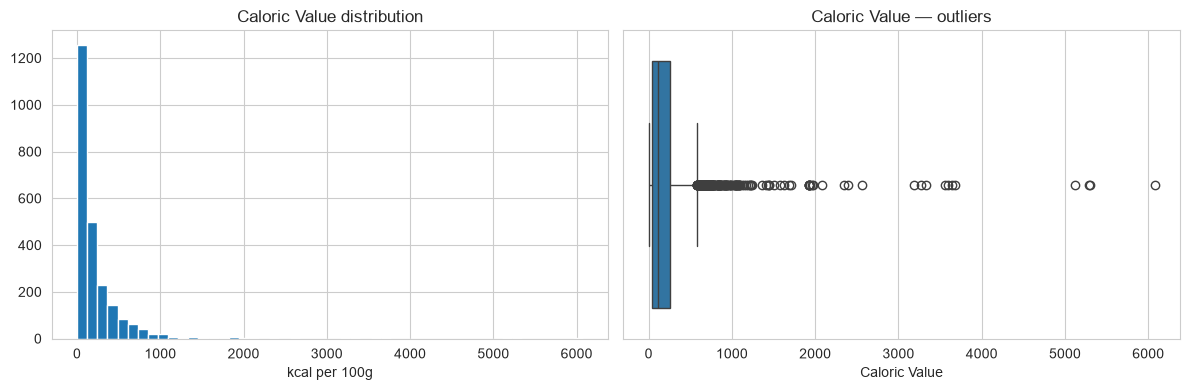

count    2395.000000
mean      223.769520
std       384.728244
min         0.000000
25%        44.500000
50%       117.000000
75%       258.000000
max      6077.000000
Name: Caloric Value, dtype: float64

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Caloric Value'].hist(bins=50, ax=axes[0])
axes[0].set_title('Caloric Value distribution')
axes[0].set_xlabel('kcal per 100g')

sns.boxplot(x=df['Caloric Value'], ax=axes[1])
axes[1].set_title('Caloric Value — outliers')

plt.tight_layout()
plt.show()

df['Caloric Value'].describe()

## 5. Domain-Logic Sanity Checks
Flag rows where macros are physically impossible or contradict stated calories.

Flagged rows: 257 / 2395


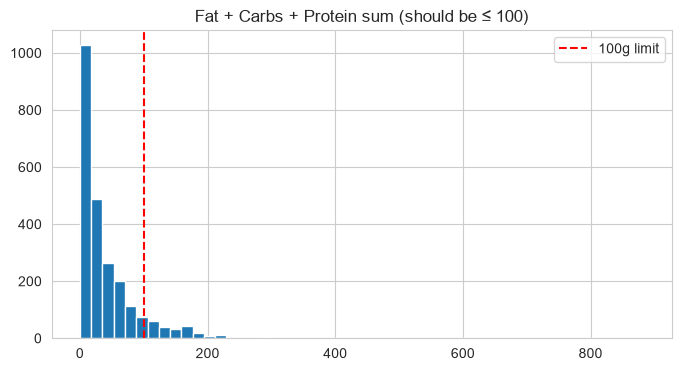

In [21]:
macro_sum = df['Fat'] + df['Carbohydrates'] + df['Protein']
df['flag_impossible_macros'] = macro_sum > 100

print(f"Flagged rows: {df['flag_impossible_macros'].sum()} / {len(df)}")

macro_sum.hist(bins=50, figsize=(8, 4))
plt.axvline(100, color='red', linestyle='--', label='100g limit')
plt.title('Fat + Carbs + Protein sum (should be ≤ 100)')
plt.legend()
plt.show()

Flagged rows: 179 / 2395


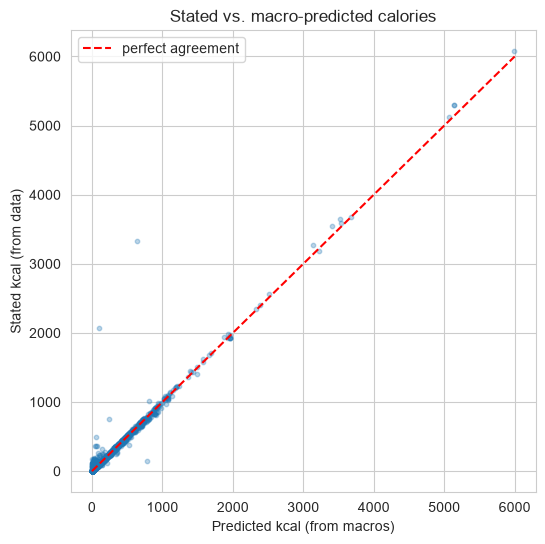

In [22]:
predicted_kcal = 9*df['Fat'] + 4*df['Carbohydrates'] + 4*df['Protein']
pct_diff = (df['Caloric Value'] - predicted_kcal).abs() / df['Caloric Value'].replace(0, 1)
df['flag_calorie_mismatch'] = pct_diff > 0.30

print(f"Flagged rows: {df['flag_calorie_mismatch'].sum()} / {len(df)}")

plt.figure(figsize=(6, 6))
plt.scatter(predicted_kcal, df['Caloric Value'], alpha=0.3, s=10)
plt.plot([0, 6000], [0, 6000], 'r--', label='perfect agreement')
plt.xlabel('Predicted kcal (from macros)')
plt.ylabel('Stated kcal (from data)')
plt.title('Stated vs. macro-predicted calories')
plt.legend()
plt.show()

## 6. Review Flagged Rows
Inspect before deciding — some flags are false positives (e.g. pure oils).

In [23]:
df[df['flag_impossible_macros']][['food', 'Fat', 'Carbohydrates', 'Protein', 'Caloric Value']] \
    .sort_values('Fat', ascending=False).head(15)

,food,Fat,Carbohydrates,Protein,Caloric Value
1437,goose meat raw,550.7,0.0,259.8,6077
1430,duck meat raw,498.8,0.0,145.7,5123
1372,pork backfat,402.3,0.0,13.2,3683
1374,pork arm picnic raw,343.4,0.0,513.6,5298
1376,pork arm picnic cooked,322.7,0.0,560.3,5292
1403,pork spareribs raw,303.5,0.0,200.6,3593
1390,pork belly raw,240.5,0.0,42.4,2350
1676,menhaden fish oil,218.0,0.0,0.0,1966
1692,nutmeg butter oil,218.0,0.0,0.0,1927
1710,babassu oil,218.0,0.0,0.0,1927


In [24]:
df[df['flag_calorie_mismatch']][['food', 'Fat', 'Carbohydrates', 'Protein', 'Caloric Value']] \
    .assign(predicted=predicted_kcal[df['flag_calorie_mismatch']].round()) \
    .head(15)

,food,Fat,Carbohydrates,Protein,Caloric Value,predicted
46,chicken spread,9.8,2.3,10.100,88,138.0
133,savoury noodle one pan dinner tandaco,1.2,5.5,0.000,172,33.0
255,little india little lunch,10.6,2.0,0.000,164,103.0
256,original chicken sandwich chick fil a,5.1,0.0,0.000,125,46.0
262,english muffin mcdonalds,2.3,2.9,5.700,97,55.0
269,egg white delight mcdonalds,16.0,0.0,0.000,250,144.0
295,chips chipotle,7.1,2.1,0.200,151,73.0
321,hand breaded chicken tenders carls jr,2.9,0.2,0.000,57,27.0
322,grilled chicken sandwich wendys,8.0,0.0,0.000,370,72.0
504,wild pink salmon oceans,16.0,0.0,0.000,320,144.0


## 7. Zero-Calorie Rows
15 rows. Some legitimate (water, salt), some errors. Check individually.

In [25]:
df[df['Caloric Value'] == 0][['food', 'Fat', 'Carbohydrates', 'Protein', 'Sugars']]

,food,Fat,Carbohydrates,Protein,Sugars
628,baking soda,0.000,0.000,0.000,0.000
743,milk chocolate with rice cereal,0.000,0.000,0.000,0.000
1025,epazote,0.060,0.094,0.059,0.000
1047,salt,0.000,0.000,0.000,0.000
1200,veal shoulder raw,0.000,0.000,0.000,0.000
1493,coffee decaffeinated,0.000,0.000,0.200,0.000
1505,powerade zero ion4 coca cola,0.000,0.000,0.000,0.000
1549,water dannon,0.000,0.000,0.000,0.000
1550,tap water,0.000,0.000,0.000,0.000
1551,table water,0.000,0.000,0.000,0.000


## 8. Apply Fixes
Drop, correct, or keep each flagged row based on the review above.

In [40]:
# --- 8a: Fix oils recorded per-cup (218g) instead of per-100g ---
oil_foods = ['menhaden fish oil', 'nutmeg butter oil', 'babassu oil',
             'tomatoseed oil', 'sheanut oil']
oil_mask = df['food'].isin(oil_foods)

# Define the explicit scaling factor (100g / 218g)
scale = 218.0 / 100.0

# Isolate numeric columns, explicitly excluding non-nutrient identifiers if present
nutrient_cols = df.select_dtypes(include='number').columns.difference(
    ['flag_impossible_macros', 'flag_calorie_mismatch', 'source_group']
)

# Convert these specific columns to float to allow decimals
df[nutrient_cols] = df[nutrient_cols].astype(float)

# Apply the division safely
df.loc[oil_mask, nutrient_cols] = df.loc[oil_mask, nutrient_cols] / scale


print("After fix:")
print(df.loc[oil_mask, ['food', 'fat', 'caloric_value']])


After fix:
                   food       fat  caloric_value
1664  menhaden fish oil  45.87156     413.685717
1680  nutmeg butter oil  45.87156     405.479337
1693        sheanut oil  45.87156     405.479337
1698        babassu oil  45.87156     405.479337
1709     tomatoseed oil  45.87156     405.479337


In [33]:
# --- 8b: Drop meat rows with impossible fat+protein combos ---
# No consistent scale factor recovers these (e.g. protein alone exceeds
# a realistic 100g serving for several rows) — unlike the oils, this
# isn't a clean unit bug, so the true values can't be reconstructed.
unfixable_meats = ['goose meat raw', 'duck meat raw', 'pork backfat',
                    'pork arm picnic raw', 'pork arm picnic cooked',
                    'pork spareribs raw', 'pork belly raw',
                    'pork backribs roasted', 'pork top loin roasts raw',
                    'pork backribs raw']

before_n = len(df)
df = df[~df['food'].isin(unfixable_meats)].reset_index(drop=True)
print(f"Dropped {before_n - len(df)} unfixable meat rows")

Dropped 10 unfixable meat rows


In [34]:
# --- 8c: Calorie mismatches — leave calories as-is ---
# Alcoholic drinks get calories from ethanol (7 kcal/g), which isn't
# captured in any macro column here, so a mismatch is expected, not an error.
# Branded items' calories are likely from an official label (trustworthy);
# their macros look incomplete, not their calories. Recomputing would
# replace a good number with a worse one, so we don't touch it.
# The flag column stays as metadata for the ML step later.
print(f"Calorie-mismatch rows kept as-is: {df['flag_calorie_mismatch'].sum()}")

Calorie-mismatch rows kept as-is: 179


In [35]:
# --- 8d: Drop the two genuine zero-calorie errors ---
# Everything else zero-calorie (water, salt, baking soda, diet soda, herbs)
# is legitimately near-zero and correct — only these two are impossible.
zero_cal_errors = ['milk chocolate with rice cereal', 'veal shoulder raw']

before_n = len(df)
df = df[~df['food'].isin(zero_cal_errors)].reset_index(drop=True)
print(f"Dropped {before_n - len(df)} zero-calorie error rows")

Dropped 2 zero-calorie error rows


In [42]:
# --- 8e: Re-run flags to confirm fixes worked ---
macro_sum = df['fat'] + df['carbohydrates'] + df['protein']
df['flag_impossible_macros'] = macro_sum > 100
predicted_kcal = 9*df['fat'] + 4*df['carbohydrates'] + 4*df['protein']
pct_diff = (df['caloric_value'] - predicted_kcal).abs() / df['caloric_value'].replace(0, 1)
df['flag_calorie_mismatch'] = pct_diff > 0.30

print(f"Remaining impossible-macro rows: {df['flag_impossible_macros'].sum()}")
print(f"Remaining calorie-mismatch rows: {df['flag_calorie_mismatch'].sum()} (expected — alcohol/branded, not errors)")
print(f"Final shape: {df.shape}")

Remaining impossible-macro rows: 242
Remaining calorie-mismatch rows: 179 (expected — alcohol/branded, not errors)
Final shape: (2383, 37)


## 9. Final Verification & Save
Re-check flags post-cleaning, export the cleaned file.

In [26]:
print(f"Final shape: {df.shape}")
print(f"Remaining impossible-macro rows: {df['flag_impossible_macros'].sum()}")
print(f"Remaining calorie-mismatch rows: {df['flag_calorie_mismatch'].sum()}")

df.columns = df.columns.str.lower().str.replace(' ', '_')
df.to_csv('../data/food_data_clean.csv', index=False)

Final shape: (2395, 37)
Remaining impossible-macro rows: 257
Remaining calorie-mismatch rows: 179
